<a href="https://colab.research.google.com/github/peremartra/optipfair/blob/main/examples/single_prompt_analysis_standalone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OptiPFair Notebook Series - Example: Single Prompt Activation Analysis (Standalone)
![optiPfair Logo](https://github.com/peremartra/optipfair/blob/main/images/optiPfair.png?raw=true)
This notebook demonstrates how to capture and visualize internal activations for a single text prompt, using the same logic as [OptiPFair](https://github.com/peremartra/optipfair)'s public bias API.

**This is a standalone version**: instead of importing `optipfair`, the bias-analysis functions (`get_prompt_activations`, `visualize_prompt_heatmap`, `visualize_prompt_layer_heatmap`, and their helpers) are reimplemented locally in Section 2, so this notebook has no dependency on the `optipfair` package — only `transformers`, `torch`, `numpy`, and `matplotlib`.

It inspects what happens inside MLP layers (gate projection, up projection and down projection input) when a model processes a given query.

## Recommended Environment
- **Platform**: [Google Colab](https://colab.research.google.com)
- **Hardware**: GPU T4 or higher (CPU also supported for small models)
- **Dependencies**: Installed in Section 0

## by Pere Martra
- [LinkedIn](https://www.linkedin.com/in/pere-martra)
- [GitHub](https://github.com/peremartra)
- [X / Twitter](https://x.com/peremartra)

---
> If you find this useful, please star the [repository](https://github.com/peremartra/optipfair).
---
If you want your favorite LLM to create code with optipfair, provide [optipfair_llm_reference_manual.txt](https://github.com/peremartra/optipfair/blob/main/optipfair_llm_reference_manual.txt).

## 0. Environment and Dependencies

In [ ]:
!pip install -q transformers torch matplotlib

## 1. Global Configuration

In [2]:
import torch

# Model
MODEL_ID = "meta-llama/Llama-3.2-1B"

# Prompt to analyze
PROMPT = "What's the most significant building in Barcelona?"

# Target layer types to capture.
# NOTE: "down_proj_input" is opt-in-only and must be listed explicitly.
TARGET_LAYERS = ["gate_proj", "up_proj", "down_proj_input"]

# Layer keys to visualize (one heatmap per key).
# Adjust the layer index to inspect a different transformer block.
LAYER_INDEX = 0
VIZ_LAYER_KEYS = [
    f"gate_proj_layer_{LAYER_INDEX}",
    f"up_proj_layer_{LAYER_INDEX}",
    f"down_proj_input_layer_{LAYER_INDEX}",
]

# Visualization parameters
BIN_SIZE = 512
CMAP = "YlOrRd"
VMAX_PERCENTILE = 99.0

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Local Implementation of OptiPFair Bias-Analysis Functions

This section reimplements, locally and verbatim, the small set of functions OptiPFair's
`optipfair.bias` module exposes for single-prompt activation analysis:

- `get_model_layers`: resolves the list of transformer decoder layers for LLaMA/Mistral/Gemma/
  Qwen-style architectures (and a few other common families) purely via `hasattr` checks — no
  model-specific branching is needed since these GLU architectures all expose
  `model.model.layers` with per-layer `.self_attn`, `.mlp.gate_proj/up_proj/down_proj`, and
  `.input_layernorm`.
- `register_hooks` / `remove_hooks` / `process_prompt` / `get_prompt_activations`: forward-hook
  based activation capture.
- `get_layer_names`: sorts captured activation keys by layer index.
- `ensure_directory`: small helper used only when saving figures to disk.
- `visualize_prompt_heatmap` / `visualize_prompt_layer_heatmap`: the two plotting functions used
  below.

No behavior is changed from the library implementation — this is purely inlining the code so the
notebook has zero dependency on the `optipfair` package.

In [ ]:
import os
import logging
from typing import Dict, List, Any, Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

logger = logging.getLogger(__name__)


# --- Layer-name resolution (model-family aware) ---

def get_model_layers(model):
    """
    Extract transformer layers from a pre-trained model.
    Currently supports LLaMA, Mistral, and similar model architectures.
    """
    if hasattr(model, 'model') and hasattr(model.model, 'layers'):
        # LLaMA, Mistral, and similar architectures
        return list(model.model.layers)
    elif hasattr(model, 'transformer') and hasattr(model.transformer, 'h'):
        # GPT-2 and similar architectures
        return list(model.transformer.h)
    elif hasattr(model, 'encoder') and hasattr(model.encoder, 'layer'):
        # BERT and similar architectures
        return list(model.encoder.layer)
    elif hasattr(model, 'layers'):
        # Direct layers attribute
        return list(model.layers)

    print("Warning: Could not find layers in the model")
    return []


# --- Activation capture: hook registration / removal / prompt processing ---

# Allowed target layers to prevent accidental string matching.
ALLOWED_TARGET_LAYERS = frozenset({
    "gate_proj", "up_proj", "down_proj", "down_proj_input", "mlp_output", "attention", "input_norm"
})

# Layers that must be explicitly requested and are never captured by default
# (i.e. when target_layers=None).
_OPT_IN_ONLY_LAYERS = frozenset({"down_proj_input"})


def _should_register(hook_prefix: str, target_layers: Optional[List[str]]) -> bool:
    """Check if a hook with the given prefix should be registered."""
    if target_layers is None:
        return hook_prefix not in _OPT_IN_ONLY_LAYERS
    return hook_prefix in target_layers


def register_hooks(model, target_layers: Optional[List[str]] = None) -> List[Any]:
    """
    Register hooks in the model to capture activations from various components.
    """
    if target_layers is not None:
        invalid = set(target_layers) - ALLOWED_TARGET_LAYERS
        if invalid:
            raise ValueError(
                f"Invalid target_layers: {sorted(invalid)}. "
                f"Valid options are: {sorted(ALLOWED_TARGET_LAYERS)}"
            )

    activations = {}
    model._optipfair_activations = activations

    handles = []

    def hook_fn(name):
        def hook(module, input, output):
            if isinstance(output, tuple):
                activations[name] = output[0].detach().cpu()
            else:
                activations[name] = output.detach().cpu()
        return hook

    def hook_fn_input(name):
        def hook(module, inputs):
            activations[name] = inputs[0].detach().cpu()
        return hook

    layers = get_model_layers(model)

    if not layers:
        logger.warning(
            "No hooks were registered. The model architecture may not be supported."
        )
        return handles

    for i, layer in enumerate(layers):
        # 1. Hook self-attention output
        if _should_register("attention", target_layers):
            if hasattr(layer, "self_attn"):
                handles.append(
                    layer.self_attn.register_forward_hook(
                        hook_fn(f"attention_output_layer_{i}")
                    )
                )

        # 2. Hook MLP output
        if hasattr(layer, "mlp"):
            if _should_register("mlp_output", target_layers):
                handles.append(
                    layer.mlp.register_forward_hook(
                        hook_fn(f"mlp_output_layer_{i}")
                    )
                )

            # 3. Hook GLU components for detailed analysis
            if _should_register("gate_proj", target_layers):
                if hasattr(layer.mlp, "gate_proj"):
                    handles.append(
                        layer.mlp.gate_proj.register_forward_hook(
                            hook_fn(f"gate_proj_layer_{i}")
                        )
                    )

            if _should_register("up_proj", target_layers):
                if hasattr(layer.mlp, "up_proj"):
                    handles.append(
                        layer.mlp.up_proj.register_forward_hook(
                            hook_fn(f"up_proj_layer_{i}")
                        )
                    )

            if _should_register("down_proj", target_layers):
                if hasattr(layer.mlp, "down_proj"):
                    handles.append(
                        layer.mlp.down_proj.register_forward_hook(
                            hook_fn(f"down_proj_layer_{i}")
                        )
                    )

            if _should_register("down_proj_input", target_layers):
                if hasattr(layer.mlp, "down_proj"):
                    handles.append(
                        layer.mlp.down_proj.register_forward_pre_hook(
                            hook_fn_input(f"down_proj_input_layer_{i}")
                        )
                    )

        # 4. Hook layer norms if present
        if _should_register("input_norm", target_layers):
            if hasattr(layer, "input_layernorm"):
                handles.append(
                    layer.input_layernorm.register_forward_hook(
                        hook_fn(f"input_norm_layer_{i}")
                    )
                )

    if not handles:
        logger.warning(
            "No hooks were registered. The model architecture may not be supported."
        )

    return handles


def remove_hooks(handles: List[Any]) -> None:
    """
    Remove hooks from a model to stop capturing activations.
    """
    for handle in handles:
        handle.remove()
    logger.info(f"Removed {len(handles)} hooks")


def process_prompt(
    model: Any,
    tokenizer: Any,
    prompt: str,
    target_layers: Optional[List[str]] = None,
) -> Dict[str, torch.Tensor]:
    """
    Process a prompt through the model and capture activations.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    hooks = register_hooks(model, target_layers=target_layers)

    try:
        with torch.no_grad():
            _ = model(**inputs)

        result = {k: v.clone() for k, v in model._optipfair_activations.items()}

    except Exception as e:
        logger.error(f"Error processing prompt: {e}")
        result = {}
    finally:
        remove_hooks(hooks)
        if hasattr(model, "_optipfair_activations"):
            delattr(model, "_optipfair_activations")

    return result


def get_prompt_activations(
    model: Any,
    tokenizer: Any,
    prompt: str,
    target_layers: Optional[List[str]] = None,
) -> Dict[str, torch.Tensor]:
    """
    Get activations for a single prompt.
    """
    return process_prompt(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        target_layers=target_layers,
    )


# --- Layer-name listing helper (used by visualize_prompt_layer_heatmap) ---

def get_layer_names(activations: Dict[str, torch.Tensor], layer_type: Optional[str] = None) -> List[str]:
    """
    Get sorted layer names from activations, optionally filtered by type.
    """
    if not activations:
        return []

    if layer_type:
        layer_keys = [k for k in activations.keys() if layer_type in k]
    else:
        layer_keys = list(activations.keys())

    if not layer_keys:
        return []

    layer_dict = {}
    for k in layer_keys:
        parts = k.split('_')
        try:
            layer_num = int(parts[-1])
            layer_dict[k] = layer_num
        except (ValueError, IndexError):
            continue

    return sorted(layer_dict.keys(), key=lambda k: layer_dict[k])


# --- Directory helper (only invoked if output_dir is passed) ---

def ensure_directory(directory_path: str) -> None:
    """
    Ensure that a directory exists, creating it if necessary.
    """
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        logger.info(f"Created directory: {directory_path}")


# --- Plotting: single-layer, token x neuron-bin heatmap ---

def visualize_prompt_heatmap(
    model: Any,
    tokenizer: Any,
    prompt: str,
    layer_key: str,
    bin_size: int = 64,
    output_dir: Optional[str] = None,
    figure_format: str = "png",
    prompt_index: int = 0,
    cmap: str = "RdBu_r",
    vmax_percentile: float = 99.0,
    reduce_batch: str = "mean",
    show: bool = True,
    **params,
):
    """
    Heatmap of raw activations for a single prompt in a specific layer.

    Rows (Y-axis): token positions in the prompt.
    Columns (X-axis): neuron bins (each bin groups bin_size consecutive neurons).
    """
    layer_prefix = layer_key.split("_layer_")[0] if "_layer_" in layer_key else None
    target = [layer_prefix] if layer_prefix else None
    activations = get_prompt_activations(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        target_layers=target,
    )

    if not activations:
        logger.warning("No activations were captured for the given prompt.")
        return

    if layer_key not in activations:
        logger.warning(
            f"Layer key '{layer_key}' not found in activations. "
            f"Available: {sorted(activations.keys())}"
        )
        return

    tensor = activations[layer_key].float()

    if tensor.ndim == 3:
        tensor = tensor.mean(dim=0) if reduce_batch == "mean" else tensor[0]
    elif tensor.ndim > 3:
        while tensor.ndim > 2:
            tensor = tensor.mean(dim=0)

    n_tokens, n_neurons = tensor.shape
    effective_bin = bin_size if n_neurons >= bin_size else 1
    if effective_bin != bin_size:
        logger.warning(
            f"bin_size={bin_size} exceeds neuron dimension ({n_neurons}). Using bin_size=1."
        )
    n_bins = n_neurons // effective_bin

    trimmed = tensor[:, : n_bins * effective_bin].numpy()
    matrix = trimmed.reshape(n_tokens, n_bins, effective_bin).mean(axis=2)

    abs_bound = float(np.percentile(np.abs(matrix), vmax_percentile))
    if abs_bound == 0:
        abs_bound = 1e-12
    norm = TwoSlopeNorm(vmin=-abs_bound, vcenter=0.0, vmax=abs_bound)

    fig_height = max(4, n_tokens * 0.45 + 2.0)
    fig, ax = plt.subplots(figsize=(14, fig_height))
    fig.patch.set_facecolor("white")

    im = ax.imshow(
        matrix,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_yticks(range(n_tokens))
    ax.set_yticklabels([f"T{i}" for i in range(n_tokens)], fontsize=8)
    ax.set_ylabel("Token position", fontsize=11)

    n_xticks = min(9, n_bins)
    xtick_bins = np.linspace(0, n_bins - 1, n_xticks).astype(int)
    ax.set_xticks(xtick_bins)
    ax.set_xticklabels(
        [str(int(b * effective_bin)) for b in xtick_bins],
        fontsize=8,
        rotation=30,
    )
    ax.set_xlabel("Neuron index", fontsize=11)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(
        f"[-{abs_bound:.4f}, +{abs_bound:.4f}] (p{int(vmax_percentile)} | abs)",
        fontsize=9,
    )
    cbar.ax.tick_params(labelsize=8)

    ax.set_title(
        f"Activation Heatmap — {layer_key} | bin={effective_bin}",
        fontsize=12,
        fontweight="bold",
        pad=10,
    )
    plt.tight_layout()

    if output_dir:
        ensure_directory(output_dir)
        layer_parts = layer_key.split("_")
        layer_type_str = "_".join(layer_parts[:-1])
        layer_num = layer_parts[-1]
        filename = (
            f"prompt_heatmap_{layer_type_str}_{layer_num}"
            f"_bin{effective_bin}_prompt{prompt_index}.{figure_format}"
        )
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches="tight")
        print(f"Saved {filepath}")

    if show:
        plt.show()


# --- Plotting: cross-layer, layer x neuron-bin heatmap ---

def visualize_prompt_layer_heatmap(
    model: Any,
    tokenizer: Any,
    prompt: str,
    layer_type: str,
    bin_size: int = 64,
    output_dir: Optional[str] = None,
    figure_format: str = "png",
    prompt_index: int = 0,
    cmap: str = "RdBu_r",
    vmax_percentile: float = 99.0,
    reduce_seq: str = "mean",
    show: bool = True,
    **params,
):
    """
    Heatmap of raw activations for a single prompt across ALL transformer layers.

    Rows (Y-axis): transformer layer index (L0, L1, ..., Ln).
    Columns (X-axis): neuron bins (each bin groups bin_size consecutive neurons).
    Cell value: mean activation magnitude across all token positions in the prompt.
    """
    activations = get_prompt_activations(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        target_layers=[layer_type],
    )

    if not activations:
        logger.warning(
            f"No activations captured for layer_type='{layer_type}'. "
            f"Check that the model has this projection and layer_type is valid."
        )
        return

    layer_keys = get_layer_names(activations, layer_type)
    if not layer_keys:
        logger.warning(
            f"No keys matching layer_type='{layer_type}' found in activations. "
            f"Available keys: {sorted(activations.keys())}"
        )
        return

    n_layers = len(layer_keys)

    rows = []
    effective_bin = bin_size

    for i, key in enumerate(layer_keys):
        tensor = activations[key].float()

        if tensor.ndim == 3:
            tensor = tensor[0]
        elif tensor.ndim > 3:
            while tensor.ndim > 2:
                tensor = tensor.mean(dim=0)

        if reduce_seq == "mean":
            vec = tensor.mean(dim=0).numpy()
        else:
            vec = tensor.max(dim=0).values.numpy()

        n_neurons = len(vec)

        if i == 0:
            if n_neurons < bin_size:
                logger.warning(
                    f"bin_size={bin_size} exceeds neuron dimension ({n_neurons}). "
                    f"Using bin_size=1."
                )
                effective_bin = 1
            else:
                effective_bin = bin_size

        n_bins = n_neurons // effective_bin
        trimmed = vec[: n_bins * effective_bin]
        row = trimmed.reshape(n_bins, effective_bin).mean(axis=1)
        rows.append(row)

    matrix = np.stack(rows)

    abs_bound = float(np.percentile(np.abs(matrix), vmax_percentile))
    if abs_bound == 0:
        abs_bound = 1e-12
    norm = TwoSlopeNorm(vmin=-abs_bound, vcenter=0.0, vmax=abs_bound)

    fig_height = max(4, n_layers * 0.52 + 2.5)
    fig, ax = plt.subplots(figsize=(14, fig_height))
    fig.patch.set_facecolor("white")

    im = ax.imshow(
        matrix,
        aspect="auto",
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_yticks(range(n_layers))
    ax.set_yticklabels([f"L{i}" for i in range(n_layers)], fontsize=9)
    ax.set_ylabel("Layer", fontsize=11)

    n_bins = matrix.shape[1]
    n_xticks = min(9, n_bins)
    xtick_bins = np.linspace(0, n_bins - 1, n_xticks).astype(int)
    ax.set_xticks(xtick_bins)
    ax.set_xticklabels(
        [str(int(b * effective_bin)) for b in xtick_bins],
        fontsize=8,
        rotation=30,
    )
    ax.set_xlabel("Neuron index", fontsize=11)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(
        f"[-{abs_bound:.4f}, +{abs_bound:.4f}] (p{int(vmax_percentile)} | abs)",
        fontsize=9,
    )
    cbar.ax.tick_params(labelsize=8)

    ax.set_title(
        f"Layer × Neuron Heatmap — {layer_type} | bin={effective_bin}",
        fontsize=12,
        fontweight="bold",
        pad=10,
    )
    plt.tight_layout()

    if output_dir:
        ensure_directory(output_dir)
        filename = (
            f"prompt_layer_heatmap_{layer_type}"
            f"_bin{effective_bin}_prompt{prompt_index}.{figure_format}"
        )
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches="tight")
        print(f"Saved {filepath}")

    if show:
        plt.show()

print("Local OptiPFair bias-analysis functions defined.")

## 3. Load Model and Tokenizer

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f"Loading tokenizer: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print(f"Loading model: {MODEL_ID}")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading tokenizer: meta-llama/Llama-3.2-1B


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

Loading model: meta-llama/Llama-3.2-1B


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Model loaded successfully.
  Parameters: 1,235,814,400


## 4. Capture Single-Prompt Activations

We use `get_prompt_activations` (defined locally in Section 2) to run the model on a single
prompt and capture the internal activations for the layer types listed in `TARGET_LAYERS`.

The result is a dictionary `{layer_key: tensor}` where each tensor has shape
`(batch, seq_len, hidden_dim)`.

In [ ]:
# get_prompt_activations is defined locally in Section 2 (no optipfair import needed)

print(f"Prompt: {PROMPT!r}")
print(f"Capturing activations for layer types: {TARGET_LAYERS}")

activations = get_prompt_activations(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT,
    target_layers=TARGET_LAYERS,
)

print(f"\nCaptured {len(activations)} activation tensors:")
for key, tensor in sorted(activations.items()):
    print(f"  {key}: shape={tuple(tensor.shape)}, dtype={tensor.dtype}")

## 5. Visualize Activation Heatmaps

Each heatmap shows:
- **Y-axis (rows)**: token positions in the prompt.
- **X-axis (columns)**: neuron bins (each bin groups `BIN_SIZE` consecutive neurons).

We plot three projections from the same transformer block to compare how
the gate, up, and down_proj_input activations differ for the same prompt.

In [ ]:
# visualize_prompt_heatmap is defined locally in Section 2 (no optipfair import needed)

# --- Gate Projection ---
print(f"Heatmap: {VIZ_LAYER_KEYS[0]}")
visualize_prompt_heatmap(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT,
    layer_key=VIZ_LAYER_KEYS[0],
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
    show=True,
)

Heatmap: up_proj_layer_0


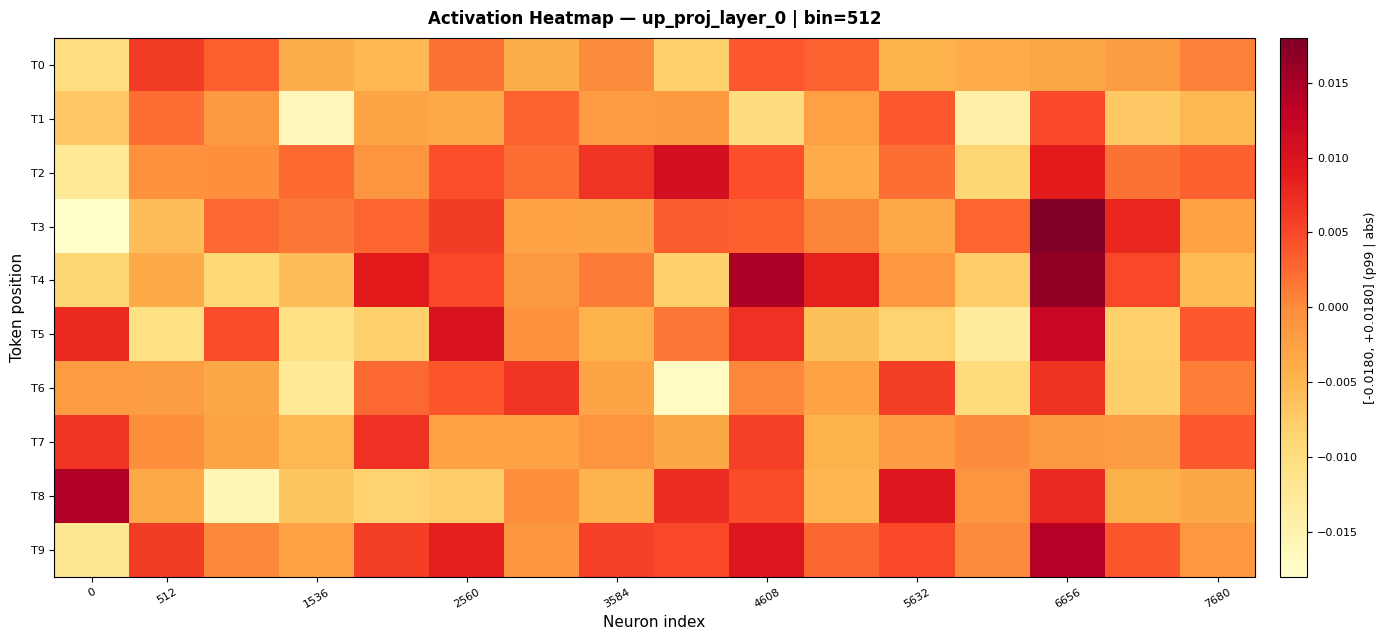

In [6]:
# --- Up Projection ---
print(f"Heatmap: {VIZ_LAYER_KEYS[1]}")
visualize_prompt_heatmap(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT,
    layer_key=VIZ_LAYER_KEYS[1],
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
    show=True,
)

Heatmap: down_proj_input_layer_0


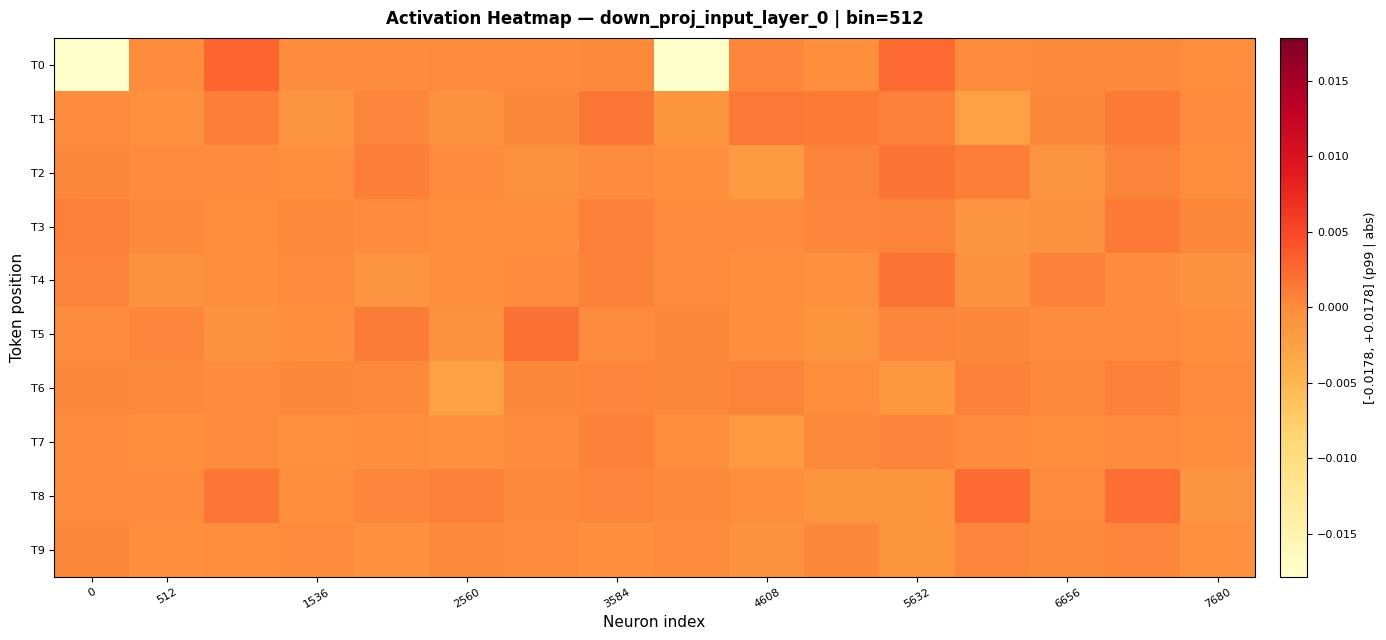

In [7]:
# --- Down Projection Input ---
# NOTE: down_proj_input captures the tensor entering the down projection
# (i.e., gate * up after the SiLU activation). It is opt-in-only and was
# explicitly requested via TARGET_LAYERS above.
print(f"Heatmap: {VIZ_LAYER_KEYS[2]}")
visualize_prompt_heatmap(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT,
    layer_key=VIZ_LAYER_KEYS[2],
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
    show=True,
)

## 6. Cross-Layer View: All Layers at Once

`visualize_prompt_layer_heatmap` (defined locally in Section 2) produces a single heatmap where:
- **Y-axis (rows)**: transformer layer index (L0, L1, …, Ln).
- **X-axis (columns)**: neuron bins (each bin groups `BIN_SIZE` consecutive neurons).
- **Cell value**: mean activation magnitude across all token positions in the prompt.

This complements the per-layer heatmaps above by showing *how activity evolves across depth* for a given projection type.

In [ ]:
# visualize_prompt_layer_heatmap is defined locally in Section 2 (no optipfair import needed)

# --- Gate Projection: all layers ---
print("Cross-layer heatmap: gate_proj")
visualize_prompt_layer_heatmap(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT,
    layer_type="gate_proj",
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
    show=True,
)

Cross-layer heatmap: up_proj


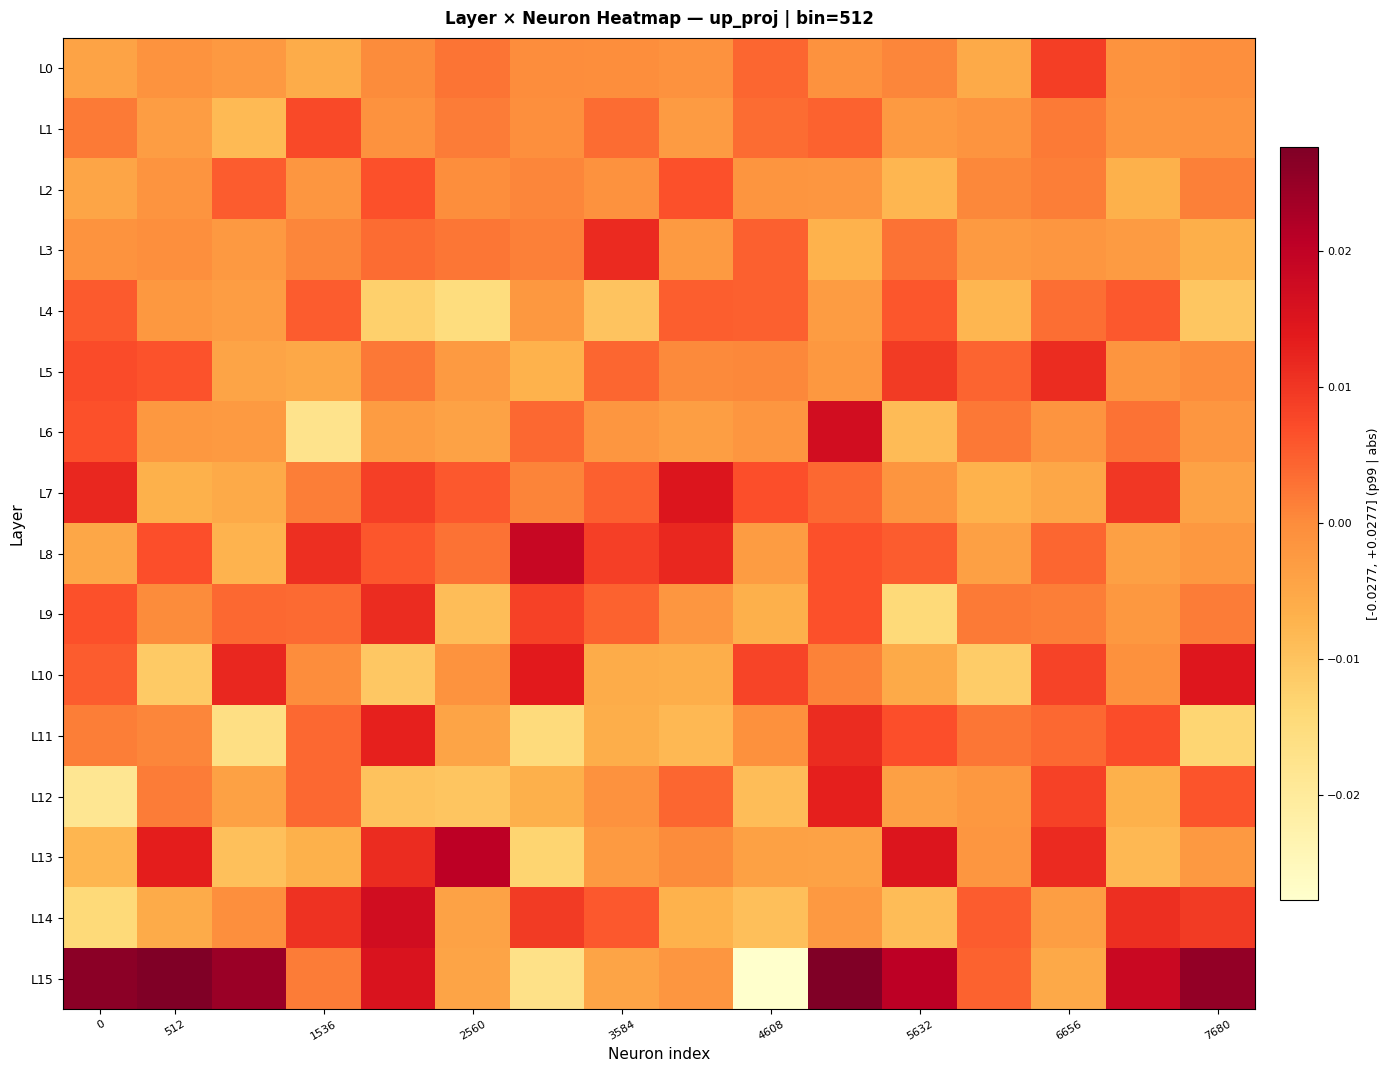

In [9]:
# --- Up Projection: all layers ---
print("Cross-layer heatmap: up_proj")
visualize_prompt_layer_heatmap(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT,
    layer_type="up_proj",
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
    show=True,
)

Cross-layer heatmap: down_proj_input


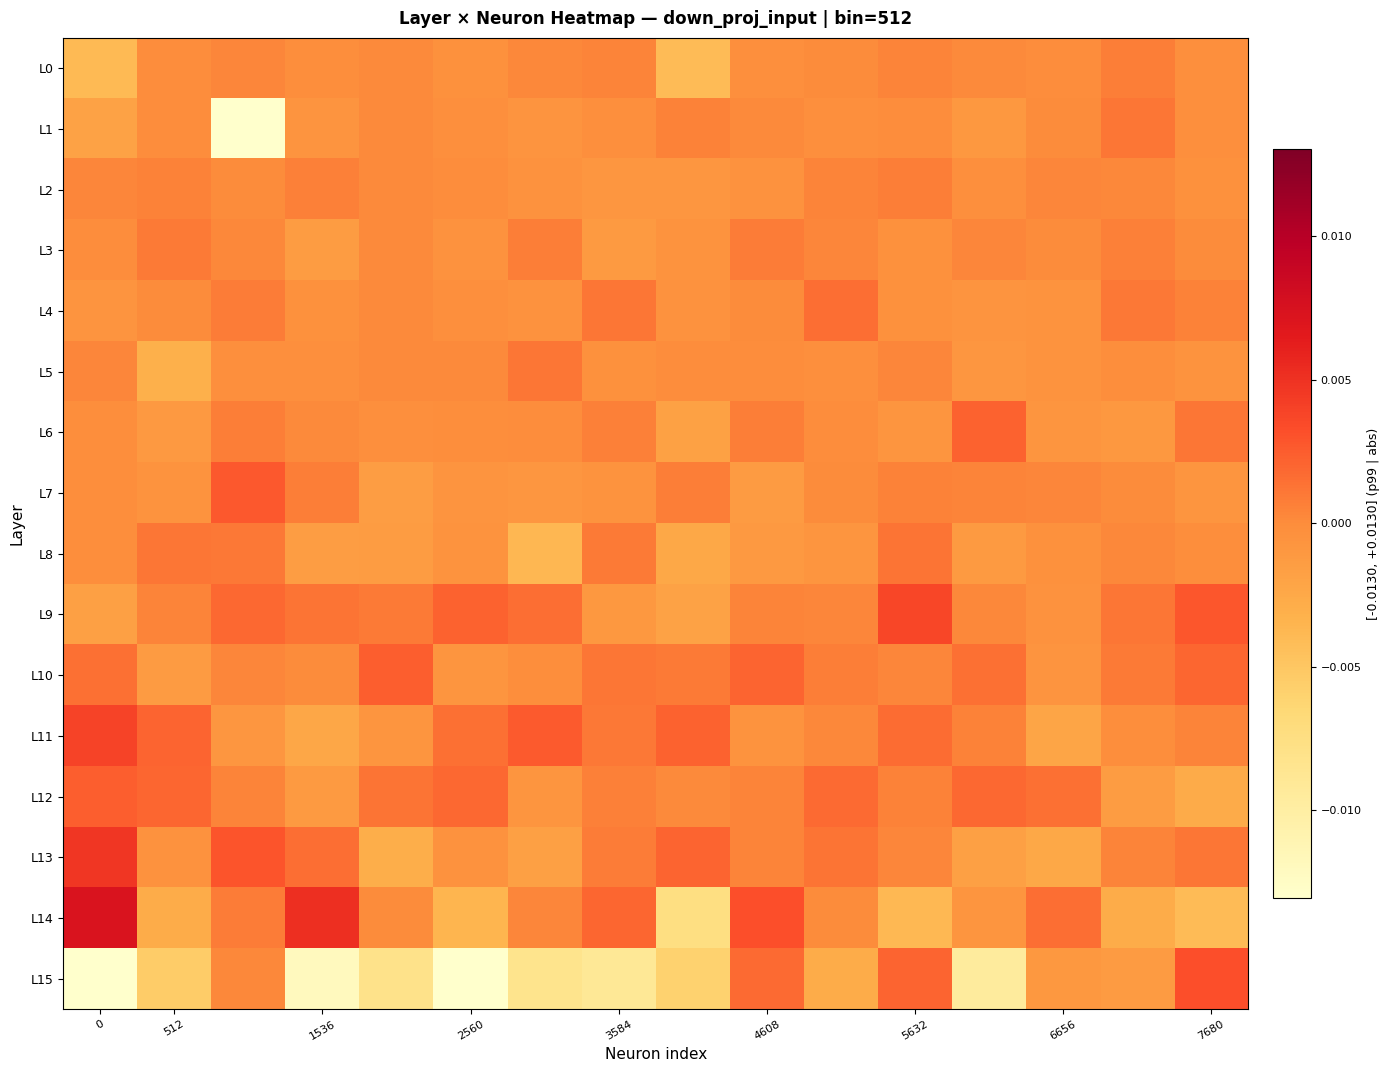

In [10]:
# --- Down Projection Input: all layers ---
# NOTE: down_proj_input is opt-in-only; visualize_prompt_layer_heatmap
# handles the capture internally via layer_type, so no extra setup is needed.
print("Cross-layer heatmap: down_proj_input")
visualize_prompt_layer_heatmap(
    model=model,
    tokenizer=tokenizer,
    prompt=PROMPT,
    layer_type="down_proj_input",
    bin_size=BIN_SIZE,
    cmap=CMAP,
    vmax_percentile=VMAX_PERCENTILE,
    show=True,
)

## 7. Summary and Next Steps

In this notebook we:
1. Loaded `meta-llama/Llama-3.2-1B` using the Hugging Face transformers library.
2. Reimplemented, locally and with no `optipfair` dependency, the bias-analysis functions
   `get_prompt_activations`, `visualize_prompt_heatmap`, and `visualize_prompt_layer_heatmap`
   (Section 2), copied verbatim from `optipfair.bias`.
3. Captured internal activations for the prompt _"What's the most significant building in Barcelona?"_
   using our local `get_prompt_activations` with explicit `target_layers`.
4. Visualized three MLP projections (gate, up, down_proj_input) as token × neuron-bin heatmaps with our local `visualize_prompt_heatmap`.
5. Visualized the same three projections across all transformer layers with our local `visualize_prompt_layer_heatmap`.

### Possible extensions

- **Change the layer index**: set `LAYER_INDEX` to a higher block (e.g. `8` or `15`) to inspect deeper representations.
- **Compare two prompts**: reimplement `get_activation_pairs` + `visualize_heatmap` locally (following the same pattern as Section 2) to measure the difference between two demographically varied prompts.
- **Save figures to disk**: pass `output_dir="./heatmaps"` to either visualization function to persist the plots.
- **Quantify bias**: reimplement the metrics module functions locally to compute numerical bias scores across layer types.
- **Use the real library**: if you want the full feature set (CLI, pruning, metrics, etc.), install `optipfair` and use `from optipfair.bias import ...` instead — see the original `single_prompt_analysis.ipynb` notebook.